### Downscale HRRR-AK Temperature with Lapse Rate

Notebook contents 
* Using the netcdf file created in `2_clean_hrrrak_netcdf.ipynb` which dealt with dimensions and crs 

created by Cassie Lumbrazo\
last updated: Jan 2026\
run location: UAS linux\
python environment: **rasterio**

In [36]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [37]:
import geopandas as gpd
from shapely.geometry import Point

In [38]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

# Load Data
## Powder Patch Station Data

In [39]:
filename = '/home/cassie/data/fishcreek/mesowest/rawdata/PPSA2_Synoptic_everything_utc_time_remove_header.csv'
df_pp= pd.read_csv(filename, sep = ",")
# Convert 'Date_Time' to datetime, skipping the first row (units row)
df_pp = df_pp.iloc[1:].copy()
df_pp['Date_Time'] = pd.to_datetime(df_pp['Date_Time'], utc=True)
# set datetime as the index
df_pp.set_index('Date_Time', inplace=True)
df_pp.head()

/tmp/ipykernel_1704782/757380401.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pp= pd.read_csv(filename, sep = ",")


,Station_ID,air_temp_set_1,relative_humidity_set_1,snow_depth_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,heat_index_set_1d,dew_point_temperature_set_1d
Date_Time,,,,,,,,,
2014-01-09 15:00:00+00:00,PPSA2,-1.43,91.9,NaN,NaN,NaN,NaN,NaN,-2.59
2014-01-09 15:30:00+00:00,PPSA2,-1.38,92.0,NaN,NaN,NaN,NaN,NaN,-2.53
2014-01-09 16:00:00+00:00,PPSA2,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 16:30:00+00:00,PPSA2,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 17:00:00+00:00,PPSA2,-1.38,91.8,NaN,NaN,NaN,NaN,NaN,-2.56


In [40]:
# create a new dataframe with only WY2024 data (Oct 1, 2023 - Sep 30, 2024)
df_pp_WY2024 = df_pp.loc['2023-10-01':'2024-09-30']
df_pp_WY2024.head()

,Station_ID,air_temp_set_1,relative_humidity_set_1,snow_depth_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,heat_index_set_1d,dew_point_temperature_set_1d
Date_Time,,,,,,,,,
2023-10-16 18:00:00+00:00,PPSA2,9.86,63.04,0.0,3266.948,13.27,0.0,NaN,3.09
2023-10-16 19:00:00+00:00,PPSA2,10.28,59.44,0.0,3266.948,13.26,0.0,NaN,2.65
2023-10-16 20:00:00+00:00,PPSA2,9.02,72.65,0.0,3266.948,13.27,0.0,NaN,4.32
2023-10-16 21:00:00+00:00,PPSA2,9.03,71.85,0.0,3266.948,13.27,0.0,NaN,4.17
2023-10-16 22:00:00+00:00,PPSA2,9.11,72.42,0.0,3266.948,13.27,0.0,NaN,4.36


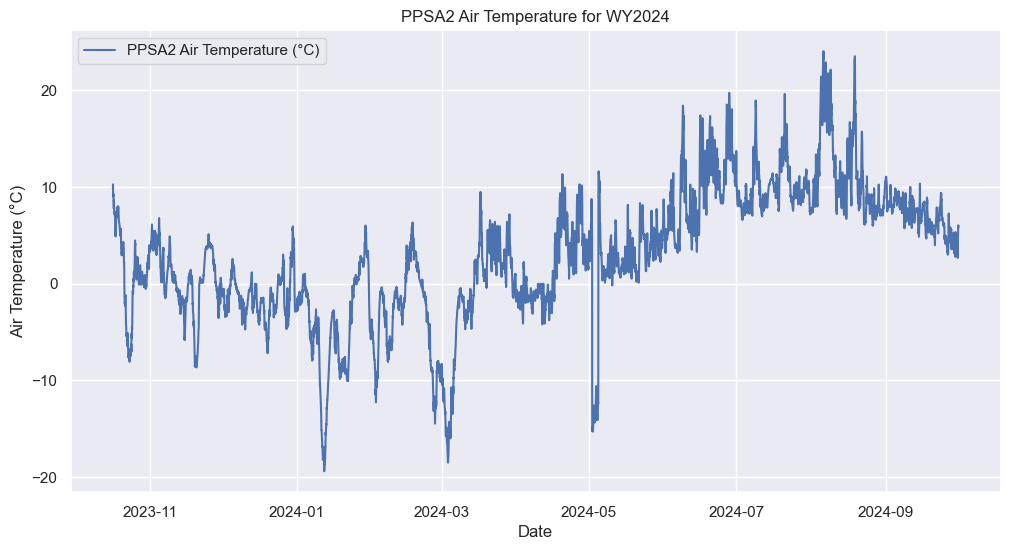

In [41]:
# and plot temperature just to take a look
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df_pp_WY2024.index, df_pp_WY2024['air_temp_set_1'], label='PPSA2 Air Temperature (°C)')
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('PPSA2 Air Temperature for WY2024')
ax.legend()
plt.show()

Text(0.5, 0, 'Date')

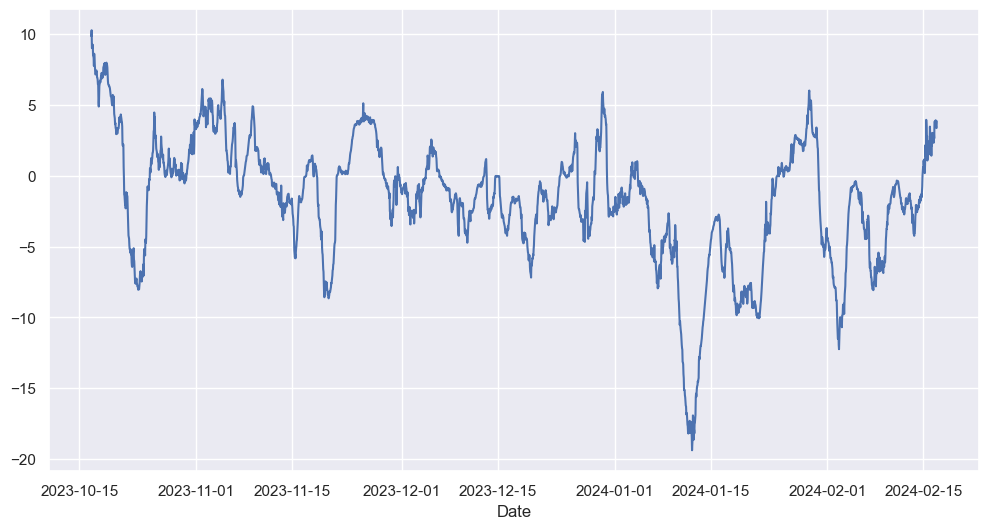

In [42]:
# Now clip even smaller to only Feb 15 2024 
df_pp_short = df_pp_WY2024.loc['2023-10-01':'2024-02-16']
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df_pp_short.index, df_pp_short['air_temp_set_1'], label='PPSA2 Air Temperature (°C)')
ax.set_xlabel('Date')

## HRRR-AK Data

In [43]:
# load the netcdf 
# hrrr_input_file = ('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1.nc') # raw hrrr data has dimension stuff going on...
hrrr_input_file = ('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1_utm.nc') # this one was created in notebook 2_clean_hrrrak_netcdf.ipynb with proper crs
ds_hrrr = xr.open_dataset(hrrr_input_file)
ds_hrrr.rio.write_crs('EPSG:32608', inplace=True) # We know we exported in UTM zone 8N, so write it and check
ds_hrrr

<xarray.Dataset> Size: 295MB
Dimensions:                  (time: 3311, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 26kB ...
    valid_time               (time) datetime64[ns] 26kB ...
  * x                        (x) float64 168B 5.039e+05 5.069e+05 ... 5.633e+05
  * y                        (y) float64 160B 6.495e+06 6.492e+06 ... 6.439e+06
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables: (12/53)
    pt                       (time, y, x) float32 6MB ...
    temp                     (time, y, x) float32 6MB ...
    d2m                      (time, y, x) float32 6MB ...
    sh2                      (time, y, x) float32 6MB ...
    rh                       (time, y, x) float32 6MB ...
    u10                      (time, y, x) float32 6MB ...
    ...                       ...
    vgtyp                    (time, y, x) float32 6MB ...
    cloud_total              (time, y, x) float32 6MB ...
    cloud_high               (time, y, x) float32 6MB ...
    cloud_low                (time, y, x) float32 6MB ...
    wind                     (time, y, x) float32 6MB ...
    temp_c                   (time, y, x) float32 6MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

In [44]:
print(ds_hrrr.rio.crs)

EPSG:32608


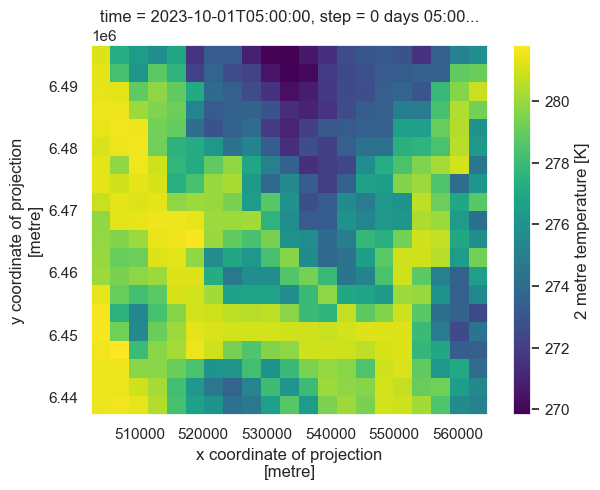

In [45]:
ds_hrrr.temp[0].plot()

In [46]:
# create a new variable in the dataset for temperature in Celsius
ds_hrrr['temp_c'] = ds_hrrr['temp'] - 273.15

### So, we are in UTM Zone 8N (EPSG:32608)

To get the Powder Patch or FAA site locations,

So I need to project the latitude/longitude coordinates (currently in WGS84) into EPSG:32608, then plot them

In [47]:
# Site coordinates (lat/lon, WGS84)
lat_faa, lon_faa = 58.26139, -134.51056
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700

# Create GeoDataFrame for the two sites
gdf_sites = gpd.GeoDataFrame({
    "site": ["FAA", "Powder Patch"],
    "geometry": [Point(lon_faa, lat_faa), Point(lon_powderpatch, lat_powderpatch)]
}, crs="EPSG:4326")

# Convert sites to same projection as dataset (UTM Zone 8N)
gdf_sites_proj = gdf_sites.to_crs("EPSG:32608")

# Extract projected coordinates
x_faa, y_faa = gdf_sites_proj.geometry[0].x, gdf_sites_proj.geometry[0].y
x_pp, y_pp = gdf_sites_proj.geometry[1].x, gdf_sites_proj.geometry[1].y

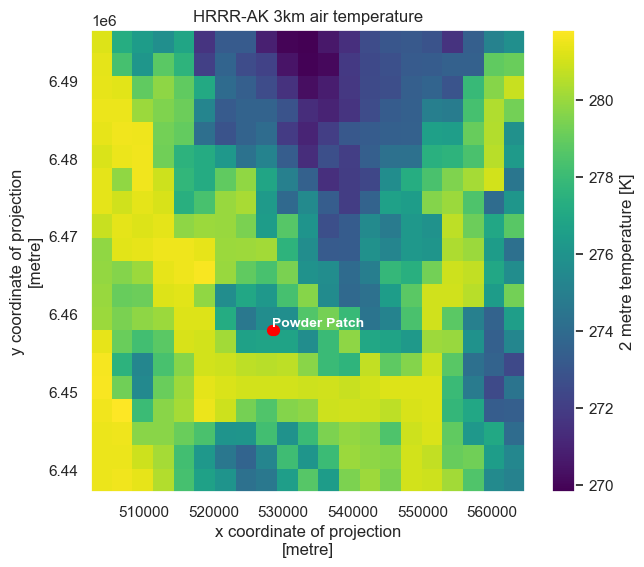

In [48]:
# Choose one time step (e.g., first one)
t0 = ds_hrrr.time[0]

# Select wind speed variable for that time
da_plot = ds_hrrr["temp"].sel(time=t0)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
da_plot.plot(ax=ax, cmap="viridis")

# Overlay points
ax.scatter([x_faa, x_pp], [y_faa, y_pp], color="red", s=50, zorder=3)
# ax.text(x_faa, y_faa, "FAA", color="white", fontsize=10, weight="bold", ha="left", va="bottom")
ax.text(x_pp, y_pp, "Powder Patch", color="white", fontsize=10, weight="bold", ha="left", va="bottom")

# Zoom in around the two sites
# buffer = 100  # meters (adjust for resolution)
# buffer = 1000  # would be 1km on each side
# ax.set_xlim(min(x_faa, x_pp) - buffer, max(x_faa, x_pp) + buffer)
# ax.set_ylim(min(y_faa, y_pp) - buffer, max(y_faa, y_pp) + buffer)

# ax.set_title(f"Wind Speed at {str(t0.values)[:16]}")
ax.set_title('HRRR-AK 3km air temperature')
plt.show()

and select the grid cells nearest the points 

In [49]:
# ds_faa = ds_hrrr.sel(y=lat_faa, x=lon_faa, method='nearest') # this works, but we need to be careful that the lat/lon are in UTM (meters)

# Site lat/lon
lat_faa, lon_faa = 58.26139, -134.51056
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700

# Convert to UTM Zone 8N
gdf_sites = gpd.GeoDataFrame({
    "site": ["FAA", "Powder Patch"],
    "geometry": [Point(lon_faa, lat_faa), Point(lon_powderpatch, lat_powderpatch)]
}, crs="EPSG:4326").to_crs("EPSG:32608")

x_faa, y_faa = gdf_sites.geometry[0].x, gdf_sites.geometry[0].y
x_pp, y_pp = gdf_sites.geometry[1].x, gdf_sites.geometry[1].y

# Select nearest grid cells
ds_faa = ds_hrrr.sel(x=x_faa, y=y_faa, method="nearest")
ds_pp = ds_hrrr.sel(x=x_pp, y=y_pp, method="nearest")

print(ds_faa)
print(ds_pp)

<xarray.Dataset> Size: 781kB
Dimensions:                  (time: 3311)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 26kB ...
    valid_time               (time) datetime64[ns] 26kB ...
    x                        float64 8B 5.276e+05
    y                        float64 8B 6.456e+06
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables: (12/53)
    pt                       (time) float32 13kB ...
    temp                     (time) float32 13kB 276.8 276.7 ... 276.0 275.9
    d2m                      (time) float32 13kB ...
    sh2                      (time) float32 13kB ...
    rh                       (time) float32 13kB ...
    u10                      (time) float32 13kB ...
    ...                       ...
    vgtyp                    (time) float32 13kB ...
    cloud_total              (time) float32 13kB ...
    cloud_high          

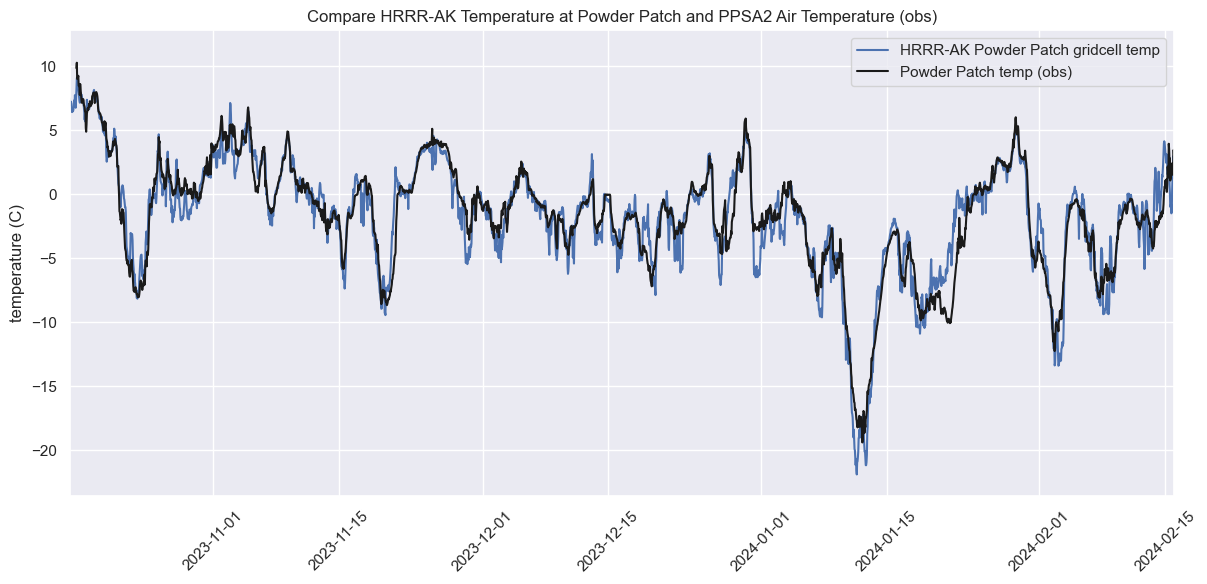

In [50]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_pp['time'].values, ds_pp['temp_c'].values, color='b', label='HRRR-AK Powder Patch gridcell temp')
# plt.plot(ds_faa['time'].values, ds_faa['temp_c'].values, color='r')

plt.plot(df_pp_short.index, df_pp_short['air_temp_set_1'], label='Powder Patch temp (obs)', color='k')

plt.title('Compare HRRR-AK Temperature at Powder Patch and PPSA2 Air Temperature (obs)')
# plt.xlabel('Time')
plt.ylabel('temperature (C)')
plt.legend()
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()

# zoom into a few days only on the xaxis
plt.xlim(pd.to_datetime('2023-10-16'), pd.to_datetime('2024-02-16'))
# plt.xlim(pd.to_datetime('2024-02-10'), pd.to_datetime('2024-02-16'))

plt.show()

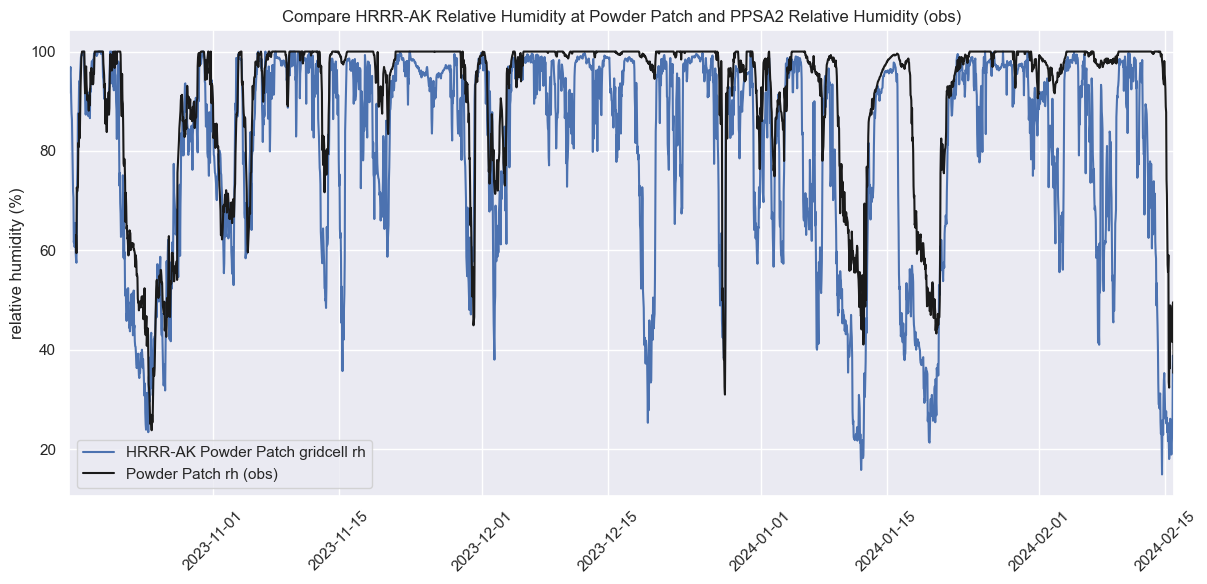

In [51]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_pp['time'].values, ds_pp['rh'].values, color='b', label='HRRR-AK Powder Patch gridcell rh')
# plt.plot(ds_faa['time'].values, ds_faa['temp_c'].values, color='r')

plt.plot(df_pp_short.index, df_pp_short['relative_humidity_set_1'], label='Powder Patch rh (obs)', color='k')

plt.title('Compare HRRR-AK Relative Humidity at Powder Patch and PPSA2 Relative Humidity (obs)')
# plt.xlabel('Time')
plt.ylabel('relative humidity (%)')
plt.legend()
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()

# zoom into a few days only on the xaxis
plt.xlim(pd.to_datetime('2023-10-16'), pd.to_datetime('2024-02-16'))
# plt.xlim(pd.to_datetime('2024-02-10'), pd.to_datetime('2024-02-16'))

plt.show()

# DEM

Last piece, open the DEM

EPSG:32608


Text(0.5, 1.0, 'DEM at Powder Patch (10m resolution)')

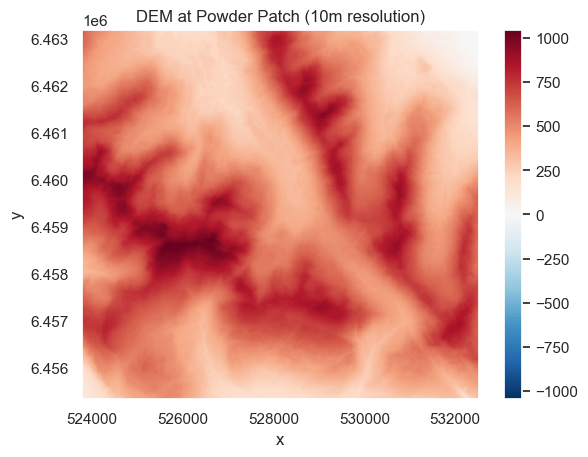

In [52]:
# open the DEM 
DEM_FILE = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif"

# open the DEM 
dem = rioxarray.open_rasterio(DEM_FILE, masked=True)
print(dem.rio.crs)
dem.plot()
plt.title('DEM at Powder Patch (10m resolution)')

# Downscale Temperature

### Resample DEM to a target resolution

In [53]:
from rasterio.enums import Resampling

In [54]:
def resample_dem(dem, resolution_m, resampling=Resampling.average):
    """
    Resample DEM to a specified resolution (meters).

    Parameters
    ----------
    dem : xarray.DataArray
        DEM with CRS set and units in meters
    resolution_m : float
        Target resolution in meters
    resampling : rasterio.enums.Resampling
        Resampling method (default: average)

    Returns
    -------
    dem_resampled : xarray.DataArray
    """
    dem_resampled = dem.rio.reproject(
        dem.rio.crs,
        resolution=resolution_m,
        resampling=resampling
    )
    return dem_resampled


### Regrid HRRR fields to the DEM grid

In [55]:
def regrid_to_dem(ds_hrrr, dem_target):
    """
    Regrid HRRR temperature and orography to DEM grid.

    Returns
    -------
    temp_ref : DataArray (time, y, x)
    z_ref    : DataArray (y, x)
    """
    temp_ref = ds_hrrr["temp_c"].rio.reproject_match(dem_target)
    z_ref = ds_hrrr["orog"].rio.reproject_match(dem_target)

    return temp_ref, z_ref


### Apply lapse-rate downscaling 
which is exactly what MeteoIO does internally for TA::LAPSE_RATE

In [56]:
def lapse_rate_downscale(temp_ref, z_ref, z_target, lapse_rate=-6.5e-3):
    """
    Apply lapse-rate temperature correction.

    Parameters
    ----------
    temp_ref : DataArray (time, y, x)
        Reference temperature (°C)
    z_ref : DataArray (y, x)
        Reference elevation (m)
    z_target : DataArray (y, x)
        Target elevation (m)
    lapse_rate : float
        Lapse rate in °C m-1 (negative)

    Returns
    -------
    temp_downscaled : DataArray (time, y, x)
    """
    dz = z_target - z_ref
    temp_downscaled = temp_ref + lapse_rate * dz
    return temp_downscaled


### Full Downscaling Loop (multi-res to experiment)

In [57]:
resolutions = [500, 200, 100, 50, 10]  # meters
lapse_rate = -6.5e-3  # °C m-1

downscaled = {}

for res in resolutions:
    print(f"Downscaling to {res} m")

    dem_res = resample_dem(dem, res)

    temp_ref, z_ref = regrid_to_dem(ds_utm, dem_res)

    temp_ds = lapse_rate_downscale(
        temp_ref=temp_ref,
        z_ref=z_ref,
        z_target=dem_res,
        lapse_rate=lapse_rate
    )

    downscaled[res] = temp_ds


Downscaling to 500 m


NameError: name 'ds_utm' is not defined

In [ ]:
# save all to new ds 
da_500m = downscaled[500]
da_200m = downscaled[200]
da_100m = downscaled[100]
da_50m = downscaled[50]
da_10m = downscaled[10]


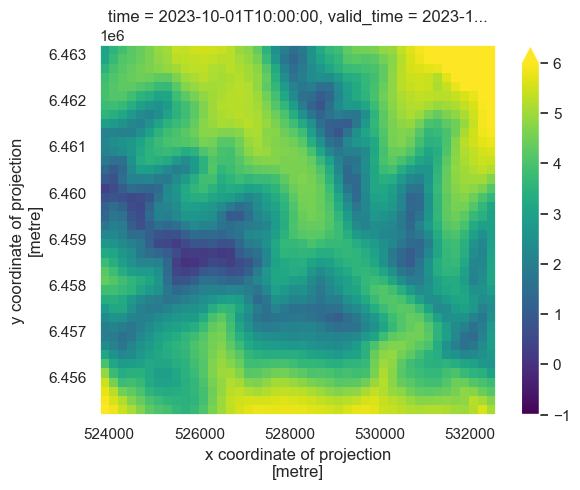

In [ ]:
da_200m.isel(time=5).plot(vmin=-1, vmax=6, cmap='viridis')

Add Powder Patch Point to the figure, 

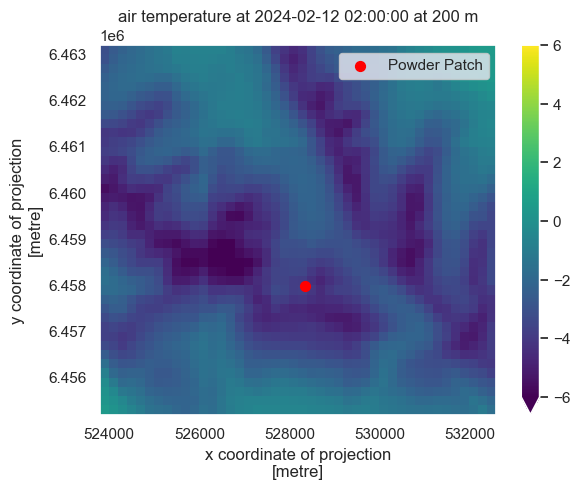

In [ ]:
target_time = pd.Timestamp("2024-02-12 2:00")

fig, ax = plt.subplots()

im = da_200m.sel(time=target_time).plot(
    ax=ax,
    vmin=-6,
    vmax=6,
    cmap="viridis"
)

ax.scatter(
    x_pp,
    y_pp,
    color="red",
    s=50,
    zorder=3,
    label="Powder Patch"
)

res = 200

ax.set_title(f"air temperature at {target_time} at {res} m")
ax.legend()
plt.show()

In [ ]:
def plot_temp_at_time(
    da,
    target_time,
    x,
    y,
    resolution_m,
    vmin=-5,
    vmax=2,
    cmap="viridis"
):
    """
    Plot air temperature at a given time and resolution with station overlay.
    """

    da_t = da.sel(time=target_time, method="nearest")
    actual_time = pd.to_datetime(da_t.time.values)

    fig, ax = plt.subplots()

    da_t.plot(
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap
    )

    ax.scatter(
        x,
        y,
        color="red",
        s=50,
        zorder=3,
        label="Powder Patch"
    )

    ax.set_title(f"air temperature at {actual_time} at {resolution_m} m")
    ax.legend()

    plt.show()

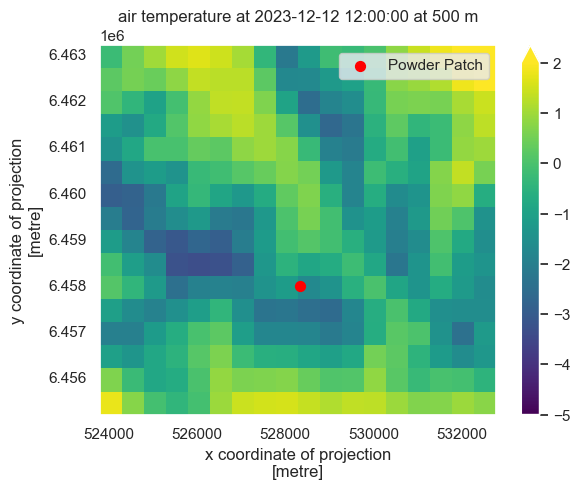

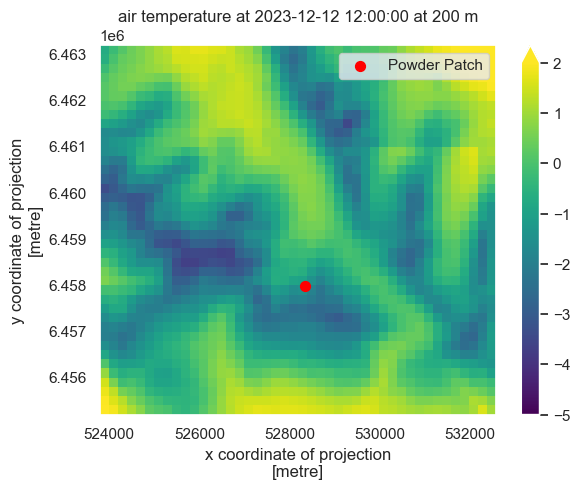

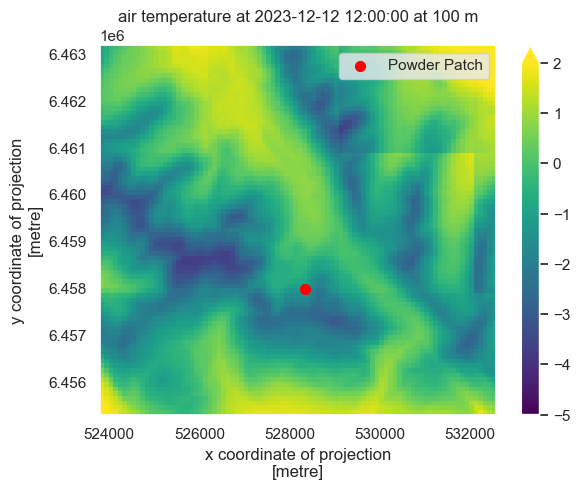

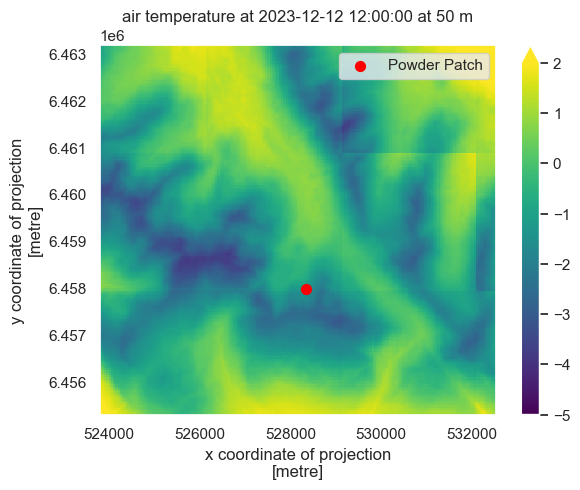

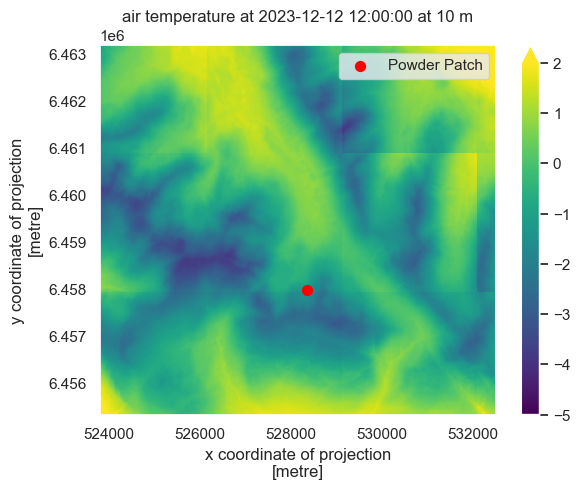

In [ ]:
plot_temp_at_time(da_500m, "2023-12-12 12:00", x_pp, y_pp, resolution_m=500)
plot_temp_at_time(da_200m, "2023-12-12 12:00", x_pp, y_pp, resolution_m=200)
plot_temp_at_time(da_100m, "2023-12-12 12:00", x_pp, y_pp, resolution_m=100)
plot_temp_at_time(da_50m, "2023-12-12 12:00", x_pp, y_pp, resolution_m=50)
plot_temp_at_time(da_10m, "2023-12-12 12:00", x_pp, y_pp, resolution_m=10)


In [ ]:
print(x_pp, y_pp)
print(da_200m.rio.crs)


528340.7656649345 6457981.62778889
EPSG:32608


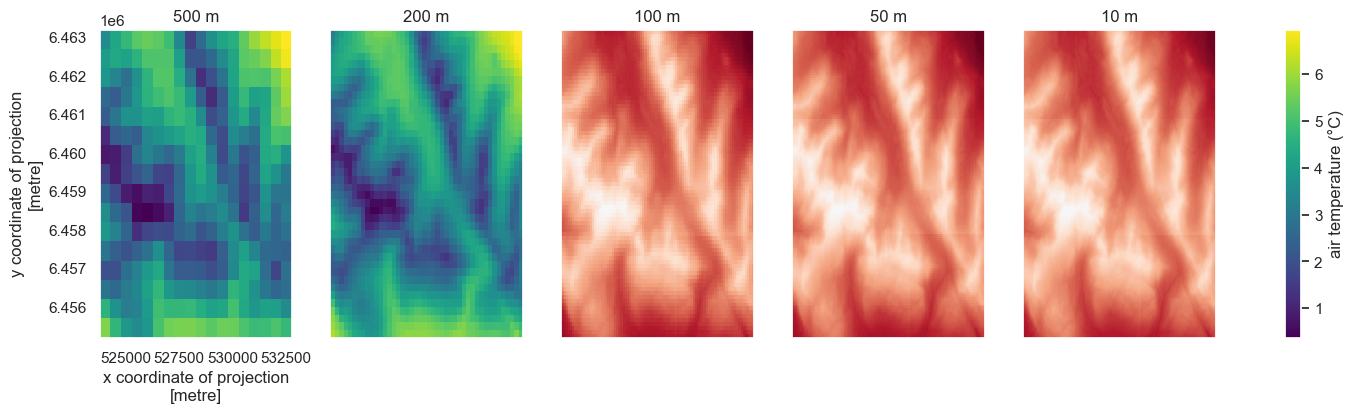

In [ ]:
time_idx = 5

fig, axes = plt.subplots(1, len(downscaled), figsize=(18, 4))

for ax, (res, da) in zip(axes, downscaled.items()):
    da.isel(time=time_idx).plot(ax=ax, add_colorbar=False)
    ax.set_title(f"{res} m")

plt.colorbar(
    axes[0].collections[0],
    ax=axes,
    label="air temperature (°C)", 
    cmap='viridis',
)

# remove the tick marks on all plots except the first 
for ax in axes[1:]:
    ax.set_xticks([])
    ax.set_yticks([])
    
    # and the x and y labels 
    ax.set_xlabel('')
    ax.set_ylabel('')


In [ ]:
da_500m_pp = da_500m.sel(x=x_pp, y=y_pp, method="nearest")
da_200m_pp = da_200m.sel(x=x_pp, y=y_pp, method="nearest")
da_100m_pp = da_100m.sel(x=x_pp, y=y_pp, method="nearest")
da_50m_pp = da_50m.sel(x=x_pp, y=y_pp, method="nearest")
da_10m_pp = da_10m.sel(x=x_pp, y=y_pp, method="nearest")

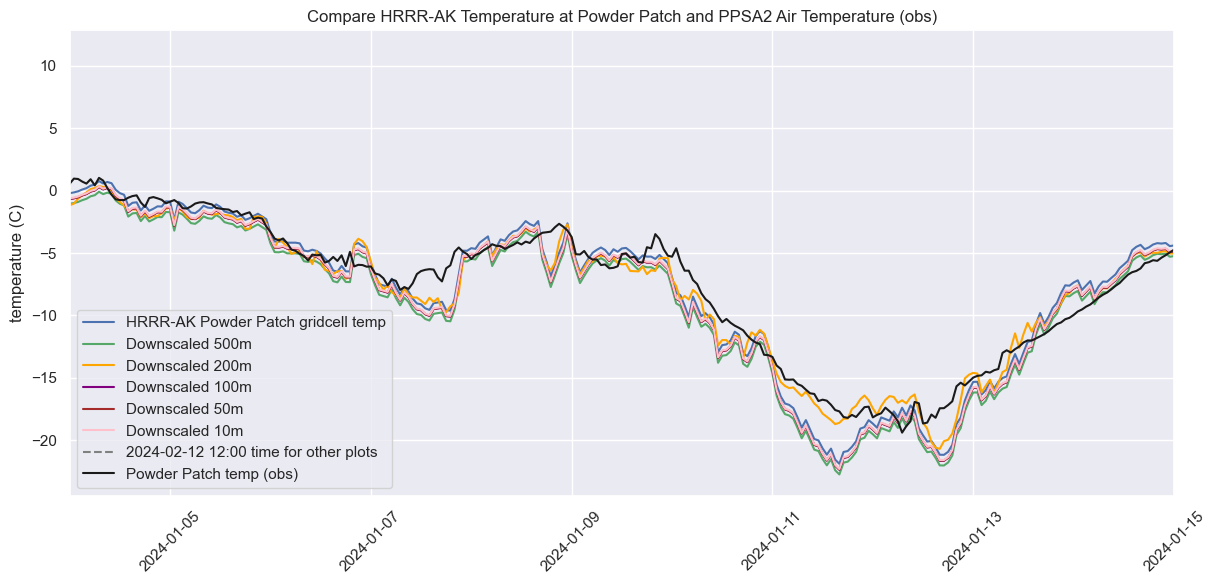

In [196]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_pp['time'].values, ds_pp['temp_c'].values, color='b', label='HRRR-AK Powder Patch gridcell temp')
plt.plot(da_500m_pp['time'].values, da_500m_pp.values, color='g', label='Downscaled 500m')
plt.plot(da_200m_pp['time'].values, da_200m_pp.values, color='orange', label='Downscaled 200m')
plt.plot(da_100m_pp['time'].values, da_100m_pp.values, color='purple', label='Downscaled 100m')
plt.plot(da_50m_pp['time'].values, da_50m_pp.values, color='brown', label='Downscaled 50m')
plt.plot(da_10m_pp['time'].values, da_10m_pp.values, color='pink', label='Downscaled 10m')

# add a verticle line in the timeseries as "2024-02-12 12:00"
plt.axvline(pd.to_datetime("2023-12-12 12:00"), color='grey', linestyle='--', label='2024-02-12 12:00 time for other plots')

plt.plot(df_pp_short.index, df_pp_short['air_temp_set_1'], label='Powder Patch temp (obs)', color='k')

plt.title('Compare HRRR-AK Temperature at Powder Patch and PPSA2 Air Temperature (obs)')
# plt.xlabel('Time')
plt.ylabel('temperature (C)')
plt.legend(loc='lower left')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()

# zoom into a few days only on the xaxis
# plt.xlim(pd.to_datetime('2023-10-16'), pd.to_datetime('2024-02-16')) # full range

# plt.xlim(pd.to_datetime('2023-12-10'), pd.to_datetime('2023-12-20')) # interesting time that is off a bit 
plt.xlim(pd.to_datetime('2024-01-04'), pd.to_datetime('2024-01-15')) # interesting time that is off a bit 

# plt.xlim(pd.to_datetime('2024-02-10'), pd.to_datetime('2024-02-16'))

plt.show()

## Distributions --- not fixed...

In [200]:
import pandas as pd

series_dict = {
    # "HRRR (3 km)": ds_pp["temp_c"].to_series(),
    "500 m": da_500m_pp.to_series(),
    "200 m": da_200m_pp.to_series(),
    "100 m": da_100m_pp.to_series(),
    "50 m": da_50m_pp.to_series(),
    "10 m": da_10m_pp.to_series(),
    "Obs": df_pp_short["air_temp_set_1"],
}

df = (
    pd.concat(series_dict, names=["resolution", "time"])
      .reset_index()
      .dropna()
)


In [201]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="resolution",
    y="value",
    showfliers=False
)

plt.ylabel("Air temperature (°C)")
plt.xlabel("")
plt.title("Air temperature distributions by resolution")
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `value` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="resolution",
    y="value",
    inner="quartile",
    cut=0
)

plt.ylabel("Air temperature (°C)")
plt.xlabel("")
plt.title("Distribution of air temperature at Powder Patch\n(2023–2024)")
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `value` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>